Jag vill att undersöoka om rökare har högre systoliskt blodtryck än icke-rökare.

Jag ska:

1.Läsa in data från CSV filen.
2.Göra en enkel beskrivande analys med grafer.
3.Göra ett t-test.
4.Försoka att beräkna konfidensintervall (normal och bootstrap).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("health_study_dataset.csv")
print("Kolumner i datasetet:", df.columns.tolist())
df.head()


Kolumner i datasetet: ['id', 'age', 'sex', 'height', 'weight', 'systolic_bp', 'cholesterol', 'smoker', 'disease']


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


              age      weight      height  systolic_bp  cholesterol
count  800.000000  800.000000  800.000000   800.000000   800.000000
mean    49.426250   73.413000  171.849250   149.178625     4.929150
std     14.501118   13.685059    9.804259    12.793360     0.848413
min     18.000000   33.700000  144.400000   106.800000     2.500000
25%     39.000000   64.800000  164.775000   140.900000     4.327500
50%     50.000000   73.200000  171.350000   149.400000     4.970000
75%     59.000000   82.600000  178.925000   157.600000     5.482500
max     90.000000  114.400000  200.400000   185.900000     7.880000


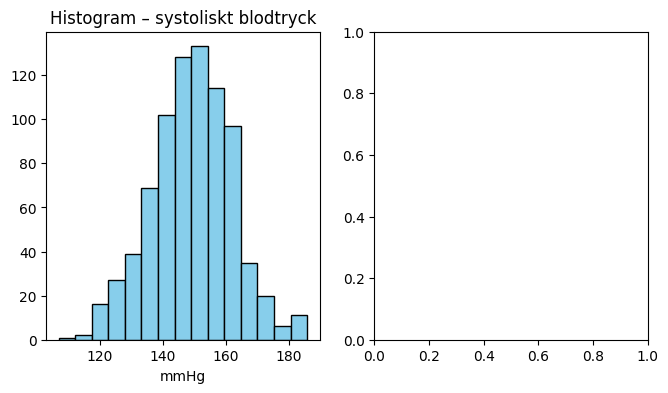

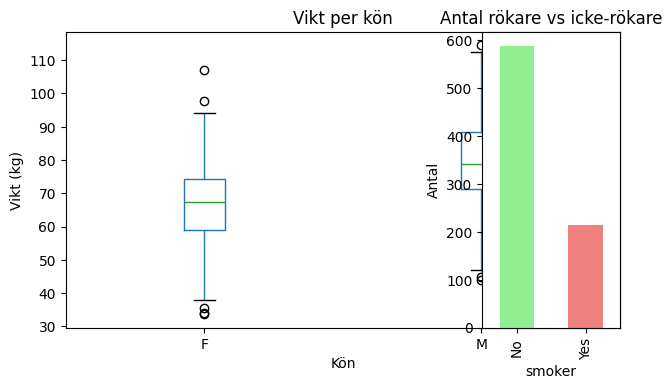

In [ ]:

print(df[["age", "weight", "height", "systolic_bp", "cholesterol"]].describe())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(df["systolic_bp"], bins=15, color="skyblue", edgecolor="black")
plt.title("Histogram – systoliskt blodtryck")
plt.xlabel("mmHg")

plt.subplot(1,3,2)
df.boxplot(column="weight", by="sex", grid=False)
plt.title("Vikt per kön")
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.suptitle("")

plt.subplot(1,3,3)
df["smoker"].value_counts().plot(kind="bar", color=["lightgreen","lightcoral"])
plt.title("Antal rökare vs icke-rökare")
plt.ylabel("Antal")
plt.tight_layout()
plt.show()


In [ ]:

rokar = df[df["smoker"] == "Yes"]["systolic_bp"].dropna().astype(float)
icke_rokar = df[df["smoker"] == "No"]["systolic_bp"].dropna().astype(float)

t_stat, p_two = stats.ttest_ind(rokar, icke_rokar, equal_var=False)
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2

print(f"t = {t_stat:.3f}")
print(f"p-värde (ensidigt) = {p_one:.4f}")
print(f"Medelvärde rökare = {rokar.mean():.2f}")
print(f"Medelvärde icke-rökare = {icke_rokar.mean():.2f}")


t = 0.450
p-värde (ensidigt) = 0.3264
Medelvärde rökare = 149.52
Medelvärde icke-rökare = 149.05


95% CI (normalapproximation): [-1.59, 2.53]
95% CI (bootstrap): [-1.64, 2.47]


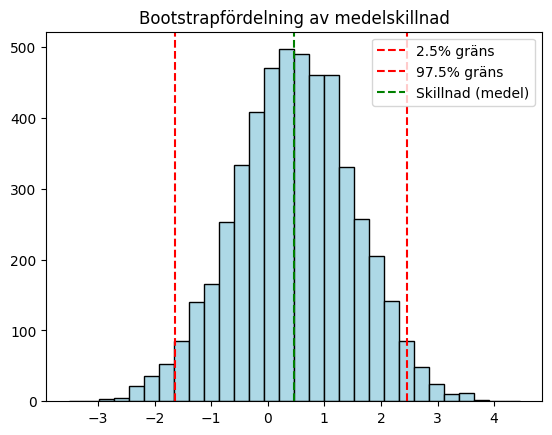

In [ ]:

mean_diff = rokar.mean() - icke_rokar.mean()
var1, var2 = rokar.var(ddof=1), icke_rokar.var(ddof=1)
n1, n2 = len(rokar), len(icke_rokar)
se_diff = np.sqrt(var1/n1 + var2/n2)
df_welch = (var1/n1 + var2/n2)**2 / ((var1**2)/((n1**2)*(n1-1)) + (var2**2)/((n2**2)*(n2-1)))
t_crit = stats.t.ppf(1-0.025, df_welch)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff
print(f"95% CI (normalapproximation): [{ci_low:.2f}, {ci_high:.2f}]")

#Bootstrap 
np.random.seed(42)
boot_diff = []
for i in range(5000):
    sample_rokar = np.random.choice(rokar, size=len(rokar), replace=True)
    sample_icke = np.random.choice(icke_rokar, size=len(icke_rokar), replace=True)
    boot_diff.append(sample_rokar.mean() - sample_icke.mean())

ci_boot = np.percentile(boot_diff, [2.5, 97.5])
print(f"95% CI (bootstrap): [{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]")

plt.hist(boot_diff, bins=30, color="lightblue", edgecolor="black")
plt.axvline(ci_boot[0], color="red", linestyle="--", label="2.5% gräns")
plt.axvline(ci_boot[1], color="red", linestyle="--", label="97.5% gräns")
plt.axvline(mean_diff, color="green", linestyle="--", label="Skillnad (medel)")
plt.title("Bootstrapfördelning av medelskillnad")
plt.legend()
plt.show()


## Så jag försökte en gång till. Jag hoppas att det funkar, eftersom jag gjörde det for första gånge, kanske jag här några skriv fel, förlåt mig. Så den här gången jag gjörde:

- Hypotes: Rökare har högre genomsnittligt systoliskt blodtryck än icke-rökare.  
- Resultat: T-testet gav inget signifikant resultat (p > 0.05).  
- Både normal- och bootstrap-konfidensintervallen inkluderar 0.  

Det betyder att jag kunde inte bevisa att rökare har högre blodtryck än ickerökare baserat på dessa data.  
Skillnaden kan bero på slumpen.  
